## 00. Imports

In [1]:
import numpy as np
import networkx as nx
import cv2
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from tensorflow.keras.datasets import mnist
from sklearn.decomposition import PCA
import concurrent.futures
import json
import os

from graph_based_codebase import preprocess_image

## 01. Download the dataset

In [2]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [3]:
img = x_train[y_train == 3][7]  # Use the first image from the training set

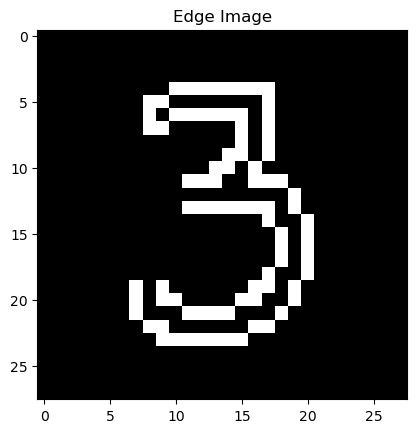

In [4]:
preprocessed = preprocess_image(img)
edges = cv2.Canny(img, threshold1=100, threshold2=125)

# Optional: show image
plt.imshow(edges, cmap='gray')
plt.title("Edge Image")
plt.show()

def plot_graph(G, ax):
    """Plot the graph on the given axis."""
    pos = {node: node for node in G.nodes()}
    nx.draw(G, pos, ax=ax, node_size=5, edge_color='gray', with_labels=False)

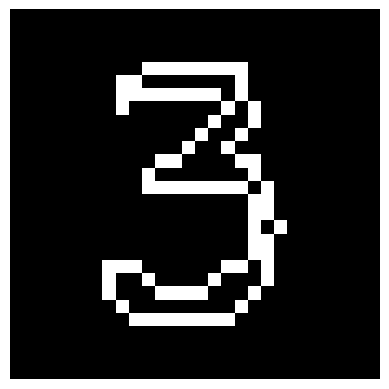

In [5]:
# Get contours (use RETR_EXTERNAL for outer contours)
contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

# display the contours
def display_contours(image, contours):
    contour_image = np.zeros_like(image)
    cv2.drawContours(contour_image, contours, -1, (255, 0, 0), 1)
    plt.imshow(contour_image, cmap='gray')
    plt.axis('off')
    plt.show()

display_contours(img, contours)

In [6]:
# Flatten to (N, 2)
points = contours[0].squeeze()

# Optional: downsample to reduce number of points
points = points[::2]


In [7]:
from submodules.schneider.fitCurves import fitCurve  # from your bezier fitting code

max_error = 10.0
beziers = fitCurve(points, max_error)

fitCurves module loaded successfully.


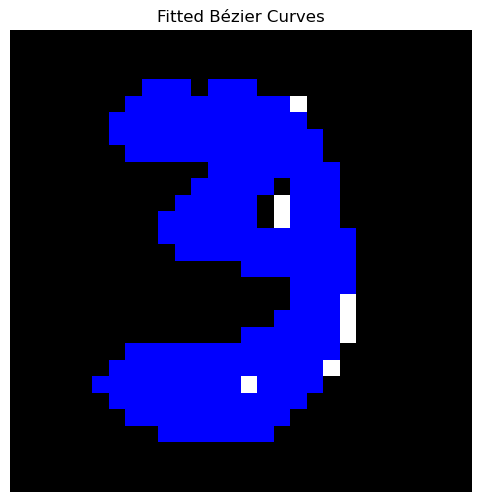

In [14]:
from submodules.schneider.bezier_sch import * 
def draw_bezier_curve(img, bezier_points, color=(0, 0, 255)):
    for curve in bezier_points:
        for t in np.linspace(0, 1, 50):
            pt = q(curve, t)
            x, y = int(pt[0]), int(pt[1])
            cv2.circle(img, (x, y), 1, color, -1)
            

# Convert to color for visualization
img_color = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)
draw_bezier_curve(img_color, beziers)

plt.figure(figsize=(6, 6))
plt.imshow(img_color)
plt.axis('off')
plt.title("Fitted Bézier Curves")
plt.show()

In [36]:
# use bezier library to fit curves

img_contour = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
#cv2.drawContours(img_contour, contours, -1, (0, 255, 0), 1)

#Step 2: Fit Bézier curves to contours using bezier library

import bezier

def fit_bezier_segments(contour, segment_length=3):
    beziers = []
    contour = contour.squeeze()
    for i in range(0, len(contour) - segment_length, segment_length):
        segment = contour[i:i + segment_length]
        if len(segment) < 2:
            continue 
        x = np.array([pt[0] for pt in segment])
        y = np.array([pt[1] for pt in segment])
        nodes = np.asfortranarray([x, y])
        degree = min(len(x) - 1, 3)  # Limit to cubic
        curve = bezier.Curve(nodes[:, :degree+1], degree=degree)
        beziers.append(curve)
    return beziers


len of all_beziers: 80
First bezier curve: []


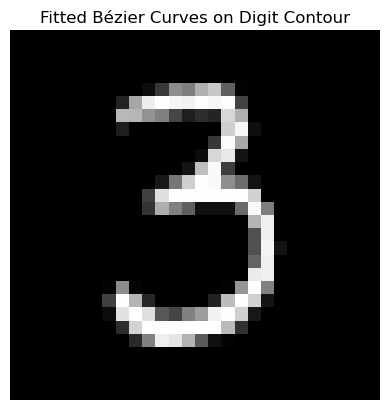

In [37]:
all_beziers = []
#contours = np.array(contours).squeeze()
#print(contours.shape)
for contour in contours:
    beziers = fit_bezier_segments(contour)
    all_beziers.append(beziers)

#Step 3: Draw the Bézier curves for visualization
print(f"len of all_beziers: {len(all_beziers)}")
print(f"First bezier curve: {all_beziers[0]}")
img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
for bezier_list in all_beziers:
    for curve in bezier_list:
        for t in np.linspace(0, 1, 100):
            pt = curve.evaluate(t)
            x, y = curve.evaluate(t).flatten()
            x, y = int(x), int(y)
            cv2.circle(img_color, (x, y), 1, (255, 0, 0), -1)


plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Fitted Bézier Curves on Digit Contour")
plt.show()